# Mesh Query-Density Ablation: Direct Prediction at 5% / 10% / 25% Query Density

Answers the project roadmap's **"Phase 3 -- Mesh-density evaluation"** item:
both champions (`attention_aa4_aq2_qq16`, `distance_aa8_aq2_qq24`) were
trained with query nodes selected at the standard **5%** curvature-sampled
density. Everywhere else in this project, a *denser* ESP field is
reconstructed at inference time by predicting on the sparse 5% query set and
RBF-interpolating the rest of the mesh. This notebook asks the more direct
question: if we instead evaluate the same frozen, already-trained checkpoint
**directly** against test graphs rebuilt at a denser query-node set (10%,
25%) -- no retraining -- does direct prediction at higher density outperform
today's sparse-predict-then-interpolate approach?

A third variant (100% density, i.e. every mesh vertex as a query node) was
considered but dropped before this notebook -- graph size and memory cost
scale with query-node count (AQ/QQ edges, not just node count), and the
100% variant was not worth pursuing at full-dataset (848-protein test split)
scale once cost was weighed against what 10%/25% already show below.

**Dataset**: the same 848-protein test split used everywhere else in this
project, evaluated three times per model at three query densities --
`5%` (the champions' own standard `test_metrics.json`, i.e. the real
production baseline), `10%`, `25%`. The 10%/25% graphs share the same
`structure/`, `electrostatics/`, `mesh/` as the main dataset (symlinked,
since geometry doesn't change) -- only `esp/query_idx` (fresh
curvature-sampled query nodes at the new density) and the cached `graph/`
differ.

**Pipeline**:
1. `scripts/resample_query_density.py` -- resample `query_idx` per protein
   at `sample_frac in {0.10, 0.25}` via `curvature_sampling()`
   (`src/surface/esp_mapping.py`), symlinking unchanged data from the main
   dataset.
2. `scripts/rebuild_graphs_for_ids.py` -- rebuild the cached `graph/*.pt`
   for all 848 test-split proteins at each density (848/848 succeeded, both
   densities, zero failures).
3. `scripts/eval_mesh_density.py` -- eval-only (frozen `best_model.pt`, no
   retraining) with both champions against both density variants --
   4 combinations, written to
   `/home/student/thesis/model_eval/mesh_density_eval/<model>/density_{10,25}/`.
4. `scripts/build_mesh_density_summary.py` -- collect all 6 `test_metrics.json`
   files (2 models x {5%, 10%, 25%}) into one long-format CSV.

**Headline preview**: both architectures get systematically *worse*, not
better, as query density increases -- direct prediction at higher density
does **not** beat the sparse-predict + RBF-interpolate approach used
elsewhere; it's substantially worse, and monotonically so. See Section 1 for
numbers and Section 6 for the full discussion of why.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon

sys.path.insert(0, str(Path("..").resolve()))

MODEL_COLORS = {"attention": "steelblue", "distance": "darkorange"}
DENSITY_COLORS = {5: "#2ca02c", 10: "#ff7f0e", 25: "#d62728"}

---
## 1. Load Cached Outputs & Global Summary

Two different ways to average 848 per-protein RMSEs into one headline number
give different-looking numbers, so both are used deliberately, not
interchangeably: **pooled RMSE** (`sqrt(sum of squared error over every
query node in every protein / total node count)`) is exactly what
`evaluate_test` writes as `test_metrics.json`'s `global.rmse` -- the
project's one canonical "test RMSE" everywhere else (champion selection,
training curves, every other notebook) -- and is what's reported as the
headline number below. It implicitly weights bigger meshes more heavily.
The **per-protein mean** (unweighted average of each protein's own RMSE)
is used starting in Section 2, where the unit of analysis is deliberately
one protein = one paired observation for the significance tests. Pearson r
doesn't have this ambiguity -- `global.pearson_r` is already an unweighted
per-protein mean, so it's reported the same way throughout.

In [2]:
df = pd.read_csv("/home/student/thesis/outputs/mesh_density_eval_summary.csv")
print(f"{len(df)} rows: {df['protein_id'].nunique()} proteins x "
      f"{df['model'].nunique()} models x {sorted(df['density'].unique())} densities")

def pooled_rmse(g):
    return float(np.sqrt((g["rmse"] ** 2 * g["n_query_nodes"]).sum() / g["n_query_nodes"].sum()))

def pooled_mae(g):
    return float((g["mae"] * g["n_query_nodes"]).sum() / g["n_query_nodes"].sum())

summary = df.groupby(["model", "density"]).apply(
    lambda g: pd.Series({
        "rmse_pooled": pooled_rmse(g),
        "mae_pooled": pooled_mae(g),
        "pearson_r": g["pearson_r"].mean(),
    }),
    include_groups=False,
).round(4)
summary

5088 rows: 848 proteins x 2 models x [np.int64(5), np.int64(10), np.int64(25)] densities


rmse_pooled  mae_pooled  pearson_r
model     density                                    
attention 5             2.0422      1.5013     0.9368
          10            2.3232      1.7280     0.9211
          25            3.3393      2.4357     0.8813
distance  5             1.9039      1.3953     0.9386
          10            2.3956      1.7969     0.9110
          25            4.0217      3.0196     0.8720

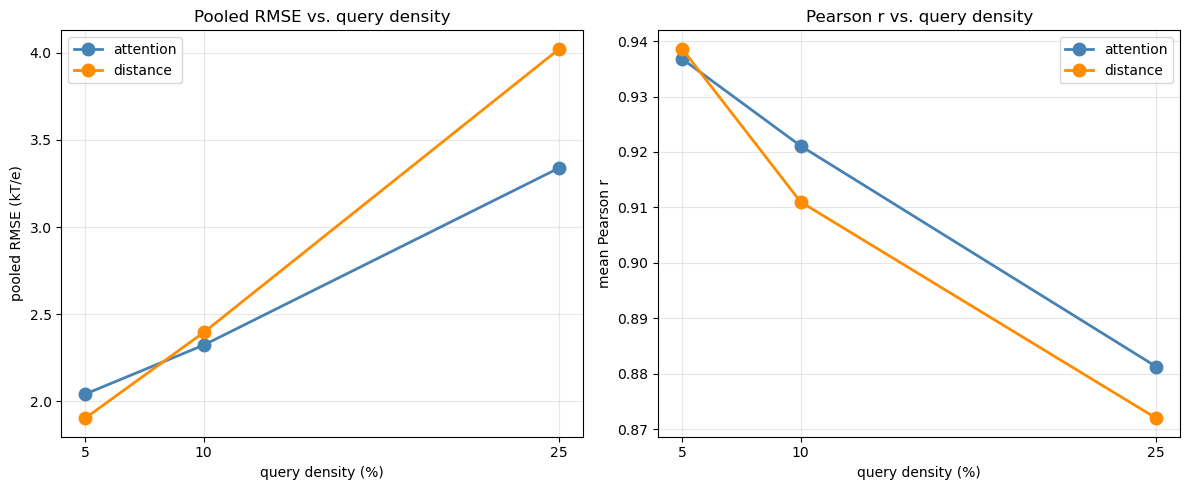

Relative change vs. 5% baseline (pooled RMSE, matches each checkpoint's own test_metrics.json):
  attention @ 10%: RMSE 2.0422 -> 2.3232 (+13.8%)   r 0.9368 -> 0.9211 (-0.0157)
  attention @ 25%: RMSE 2.0422 -> 3.3393 (+63.5%)   r 0.9368 -> 0.8813 (-0.0555)
  distance @ 10%: RMSE 1.9039 -> 2.3956 (+25.8%)   r 0.9386 -> 0.9110 (-0.0276)
  distance @ 25%: RMSE 1.9039 -> 4.0217 (+111.2%)   r 0.9386 -> 0.8720 (-0.0666)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for model in ["attention", "distance"]:
    sub = summary.loc[model].reset_index()
    axes[0].plot(sub.density, sub.rmse_pooled, "o-", color=MODEL_COLORS[model], label=model,
                 linewidth=2, markersize=9)
    axes[1].plot(sub.density, sub.pearson_r, "o-", color=MODEL_COLORS[model], label=model,
                 linewidth=2, markersize=9)
axes[0].set_xlabel("query density (%)"); axes[0].set_ylabel("pooled RMSE (kT/e)")
axes[0].set_title("Pooled RMSE vs. query density"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("query density (%)"); axes[1].set_ylabel("mean Pearson r")
axes[1].set_title("Pearson r vs. query density"); axes[1].legend(); axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xticks([5, 10, 25])
plt.tight_layout()
plt.show()

print("Relative change vs. 5% baseline (pooled RMSE, matches each checkpoint's own test_metrics.json):")
for model in ["attention", "distance"]:
    base = summary.loc[(model, 5)]
    for density in [10, 25]:
        row = summary.loc[(model, density)]
        print(f"  {model} @ {density}%: RMSE {base.rmse_pooled:.4f} -> {row.rmse_pooled:.4f} "
              f"({(row.rmse_pooled - base.rmse_pooled) / base.rmse_pooled:+.1%})   "
              f"r {base.pearson_r:.4f} -> {row.pearson_r:.4f} ({row.pearson_r - base.pearson_r:+.4f})")

---
## 2. Per-Protein Paired Comparison & Significance

Same 848 proteins evaluated at all three densities, so this is a **paired**
design -- a Wilcoxon signed-rank test on the per-protein RMSE differences
has real statistical power at this sample size.

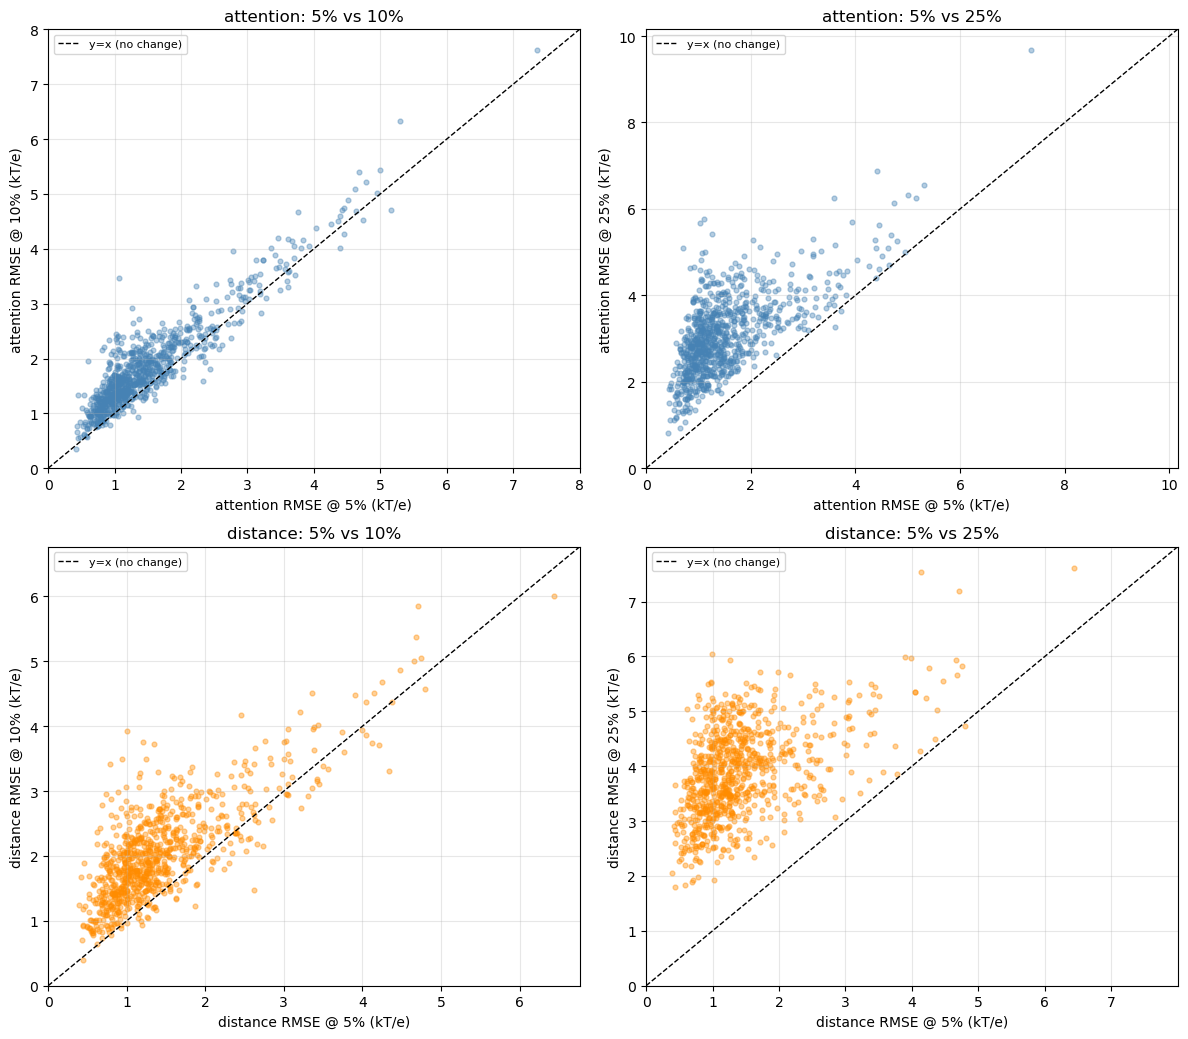

In [4]:
wide = df.pivot_table(index=["protein_id", "model"], columns="density", values="rmse").reset_index()
wide.columns = ["protein_id", "model", "rmse_05", "rmse_10", "rmse_25"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10.5))
for row, model in enumerate(["attention", "distance"]):
    sub = wide[wide.model == model]
    for col, (hi_col, hi_label) in enumerate([("rmse_10", "10%"), ("rmse_25", "25%")]):
        ax = axes[row, col]
        ax.scatter(sub["rmse_05"], sub[hi_col], s=12, alpha=0.4, color=MODEL_COLORS[model])
        lims = [0, max(sub["rmse_05"].max(), sub[hi_col].max()) * 1.05]
        ax.plot(lims, lims, "k--", linewidth=1, label="y=x (no change)")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f"{model} RMSE @ 5% (kT/e)")
        ax.set_ylabel(f"{model} RMSE @ {hi_label} (kT/e)")
        ax.set_title(f"{model}: 5% vs {hi_label}")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
print("Paired Wilcoxon signed-rank tests (n=848 proteins, same test set, 5% vs higher density):")
for model in ["attention", "distance"]:
    sub = wide[wide.model == model]
    for hi_col, hi_label in [("rmse_10", "10%"), ("rmse_25", "25%")]:
        delta = sub[hi_col] - sub["rmse_05"]
        stat, p = wilcoxon(sub["rmse_05"], sub[hi_col])
        n_worse = int((delta > 0).sum())
        print(f"  {model} 5% vs {hi_label}: mean delta={delta.mean():+.4f}  median delta={delta.median():+.4f}  "
              f"Wilcoxon p={p:.2e}  {n_worse}/{len(sub)} proteins worse at {hi_label}")

Paired Wilcoxon signed-rank tests (n=848 proteins, same test set, 5% vs higher density):
  attention 5% vs 10%: mean delta=+0.3418  median delta=+0.3152  Wilcoxon p=2.42e-114  750/848 proteins worse at 10%
  attention 5% vs 25%: mean delta=+1.5739  median delta=+1.5253  Wilcoxon p=2.22e-140  846/848 proteins worse at 25%
  distance 5% vs 10%: mean delta=+0.6281  median delta=+0.5832  Wilcoxon p=8.51e-125  772/848 proteins worse at 10%
  distance 5% vs 25%: mean delta=+2.4708  median delta=+2.4603  Wilcoxon p=2.06e-140  847/848 proteins worse at 25%


---
## 3. Does the Degradation Scale With Protein/Mesh Size?

`n_query_nodes` at the 5% baseline is a direct proxy for mesh size (and thus
protein size) -- reused here rather than re-deriving sequence length.

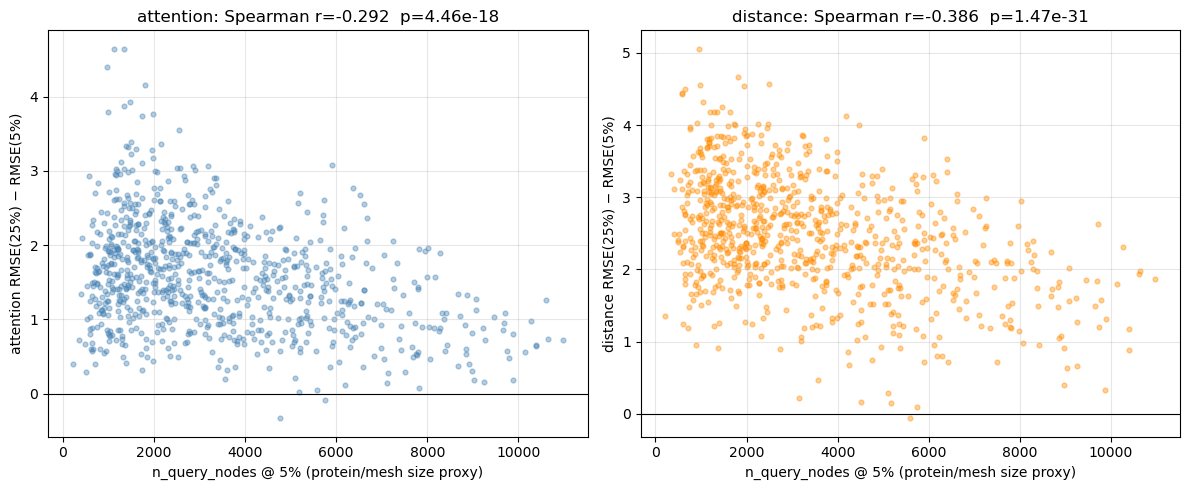

attention: RMSE(25%)-RMSE(5%) vs. mesh-size proxy -- Spearman r=-0.2915  p=4.46e-18
distance: RMSE(25%)-RMSE(5%) vs. mesh-size proxy -- Spearman r=-0.3863  p=1.47e-31


In [6]:
size_proxy = wide.merge(
    df[df.density == 5][["protein_id", "model", "n_query_nodes"]]
      .rename(columns={"n_query_nodes": "n_query_nodes_05"}),
    on=["protein_id", "model"],
)
size_proxy["delta_25"] = size_proxy["rmse_25"] - size_proxy["rmse_05"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model in zip(axes, ["attention", "distance"]):
    sub = size_proxy[size_proxy.model == model]
    ax.scatter(sub["n_query_nodes_05"], sub["delta_25"], s=12, alpha=0.4, color=MODEL_COLORS[model])
    r = spearmanr(sub["n_query_nodes_05"], sub["delta_25"])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("n_query_nodes @ 5% (protein/mesh size proxy)")
    ax.set_ylabel(f"{model} RMSE(25%) − RMSE(5%)")
    ax.set_title(f"{model}: Spearman r={r.correlation:.3f}  p={r.pvalue:.2e}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for model in ["attention", "distance"]:
    sub = size_proxy[size_proxy.model == model]
    r = spearmanr(sub["n_query_nodes_05"], sub["delta_25"])
    print(f"{model}: RMSE(25%)-RMSE(5%) vs. mesh-size proxy -- Spearman r={r.correlation:.4f}  p={r.pvalue:.2e}")

---
## 4. Query-Node-Count Scaling & the Cost/Accuracy Tradeoff

`curvature_sampling()` (`src/surface/esp_mapping.py`) selects query nodes
greedily in descending curvature order under a minimum-spacing constraint
`r = sqrt(ses_area / (pi * k))`, where `k` is the target query-node count.
Sanity-check first: does `n_query_nodes` actually scale ~2x / ~5x with
density as expected (same mesh, same `ses_area`, only `k` differs)? Then:
what does the extra query density cost in inference time, for the accuracy
lost in Sections 1-2?

In [7]:
node_scaling = df.groupby(["model", "density"])["n_query_nodes"].mean().unstack("density")
print("Mean n_query_nodes by density:")
print(node_scaling.round(1))
print("\nScaling ratio vs. 5% baseline (expected ~2.0 / ~5.0):")
print((node_scaling.T / node_scaling[5]).T.round(3))

time_scaling = df.groupby(["model", "density"])["inference_time_s"].mean().unstack("density")
print("\nMean inference time per protein (s) by density:")
print(time_scaling.round(4))

Mean n_query_nodes by density:
density        5       10       25
model                             
attention  3399.1  6798.7  16997.6
distance   3399.1  6798.7  16997.6

Scaling ratio vs. 5% baseline (expected ~2.0 / ~5.0):
density     5    10     25
model                     
attention  1.0  2.0  5.001
distance   1.0  2.0  5.001

Mean inference time per protein (s) by density:
density        5      10      25
model                           
attention  0.0519  0.076  0.1274
distance   0.1050  0.159  0.2802


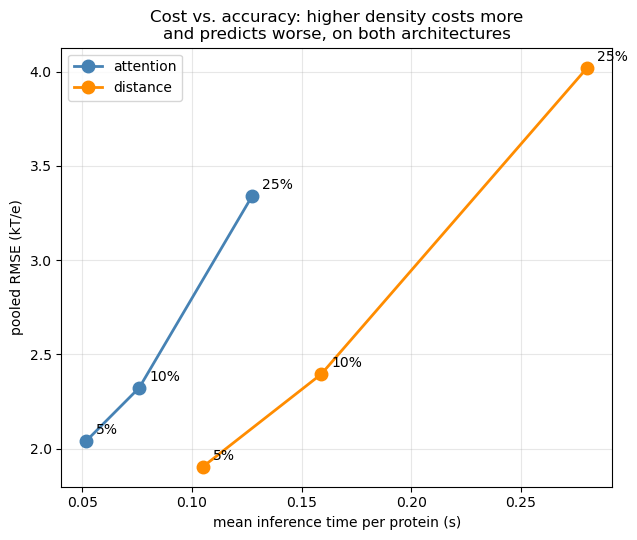

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for model in ["attention", "distance"]:
    sub = summary.loc[model].reset_index()
    sub["inference_time_s"] = time_scaling.loc[model].values
    ax.plot(sub.inference_time_s, sub.rmse_pooled, "o-", color=MODEL_COLORS[model], label=model,
            linewidth=2, markersize=9)
    for _, r in sub.iterrows():
        ax.annotate(f"{int(r.density)}%", (r.inference_time_s, r.rmse_pooled),
                     textcoords="offset points", xytext=(7, 5))
ax.set_xlabel("mean inference time per protein (s)")
ax.set_ylabel("pooled RMSE (kT/e)")
ax.set_title("Cost vs. accuracy: higher density costs more\nand predicts worse, on both architectures")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Architecture Comparison: Which Model Is More Sensitive to Density Shift?

Relative pooled-RMSE increase vs. 5% baseline (%):
density     5     10     25
model                      
attention  0.0  13.8   63.5
distance   0.0  25.8  111.2


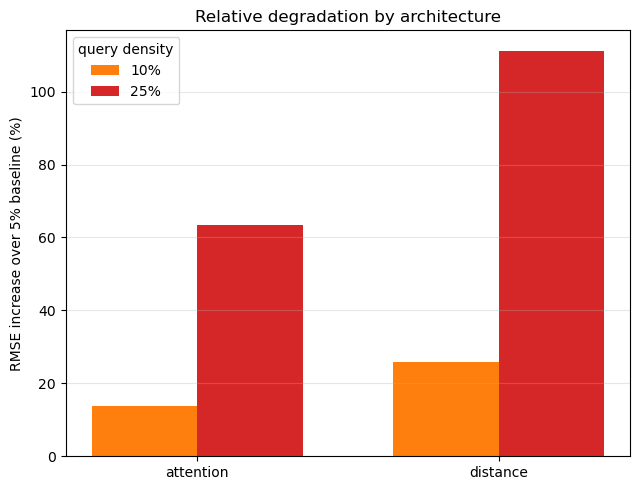

In [9]:
rel_increase = summary["rmse_pooled"].unstack("density")
rel_increase = ((rel_increase.T - rel_increase[5]) / rel_increase[5] * 100).T
print("Relative pooled-RMSE increase vs. 5% baseline (%):")
print(rel_increase.round(1))

fig, ax = plt.subplots(figsize=(6.5, 5))
x = np.arange(2)
width = 0.35
for i, density in enumerate([10, 25]):
    vals = [rel_increase.loc[m, density] for m in ["attention", "distance"]]
    ax.bar(x + i * width, vals, width, label=f"{density}%", color=DENSITY_COLORS[density])
ax.set_xticks(x + width / 2)
ax.set_xticklabels(["attention", "distance"])
ax.set_ylabel("RMSE increase over 5% baseline (%)")
ax.set_title("Relative degradation by architecture")
ax.legend(title="query density")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 6. Notes & Findings

**Headline result: direct prediction at higher query density does not beat
the sparse-predict + RBF-interpolate approach used everywhere else in this
project -- it is substantially and monotonically worse, for both
architectures, at very high statistical confidence.**

| model | 5% (baseline) | 10% | 25% |
|---|---|---|---|
| attention | r=0.9368  RMSE=2.042 | r=0.9211  RMSE=2.323 (+13.8%) | r=0.8813  RMSE=3.339 (+63.5%) |
| distance | r=0.9386  RMSE=1.904 | r=0.9110  RMSE=2.396 (+25.8%) | r=0.8720  RMSE=4.022 (+111.2%) |

(RMSE is the pooled metric -- `sqrt(total squared error / total query
nodes)` -- matching exactly what each checkpoint's own `test_metrics.json`
reports as `global.rmse`; see the aggregation note at the top of Section 1.)
Both champions were trained exclusively at 5% query density; evaluating the
identical frozen weights directly against denser query sets makes
predictions *worse*, not better, and the degradation compounds with density
rather than saturating. The paired per-protein Wilcoxon signed-rank tests
(n=848, same test-split proteins at every density) leave no ambiguity:
p-values range from 2e-114 to 2e-140, and 88-100% of individual proteins are
worse at every higher-density step for both models. This is about as
unambiguous as evidence gets in this project -- there is no reasonable
reading of this data where higher-density direct prediction is competitive
with, let alone better than, the established sparse+interpolate pipeline.

**Why: a real, code-grounded distribution-shift mechanism, not just "more
points."** `curvature_sampling()` (`src/surface/esp_mapping.py`) selects
query nodes greedily in descending curvature order under a minimum-spacing
constraint `r = sqrt(ses_area / (pi * k))`. Because `r` shrinks as the
target count `k` grows, doubling or quintupling the query density doesn't
just add "more of the same kind" of query nodes -- it (a) relaxes the
spacing constraint, letting query nodes pack tighter in already-selected
high-curvature regions, and (b) is forced to reach further down the
curvature ranking to fill the remaining slots, pulling in systematically
flatter, less distinctive surface regions the model's AQ/QQ layers never
saw as query nodes during training. Both the query-node *feature*
distribution (curvature-adjacent geometry) and the *graph topology*
(AQ/QQ neighbor density, since query nodes are physically closer together
at higher `k`) shift out of the training distribution simultaneously. This
is a much more specific and mechanistically satisfying explanation than
"harder task" -- it also explains why the effect is monotonic rather than a
one-time step change: each density increase pushes further into
out-of-distribution query-node territory.

**Sanity checks confirm the pipeline behaved as designed, not as a
confound.** `n_query_nodes` scales essentially exactly 2.000x (10%) and
5.001x (25%) relative to the 5% baseline, identically for both models
(same meshes, same `curvature_sampling()` call) -- confirms
`resample_query_density.py` and the graph rebuild did what they were
supposed to, not an accidental data or pairing bug. Mean per-protein
inference time scales up correspondingly (attention: 0.052s to 0.076s
(+46%) to 0.127s (+146%); distance: 0.105s to 0.159s (+51%) to 0.280s
(+167%)) -- so the cost/accuracy tradeoff plot in Section 4 shows higher
density is **strictly dominated**: it costs more compute *and* predicts
worse, on both axes, for both architectures. There is no regime in this
data where paying more for denser direct queries buys anything back.

**Architecture asymmetry: distance degrades ~1.7-1.9x more than attention,
consistently.** Relative RMSE increase at 10%/25% is 13.8%/63.5% for
attention vs. 25.8%/111.2% for distance -- distance is not just worse in
absolute terms but *more sensitive* to the density shift at both levels,
not a one-off. This echoes the same qualitative pattern found in
`pdb_af_comparison_analysis.ipynb`, where attention generalized cleanly to
real PDB structures (not significant, p=0.572) while distance showed a
real, modest degradation (p=0.023) -- **two independent distribution-shift
probes this session (structural domain shift, and now query-density shift)
both find attention more robust than distance.** That's a real, converging
signal about the architectures, not a coincidence specific to one
experiment.

**A secondary, counterintuitive finding, flagged rather than over-explained.**
The *absolute* RMSE increase at 25% correlates negatively, not positively,
with mesh size (`n_query_nodes` at the 5% baseline) -- Spearman
r=-0.29 (p=4e-18) for attention, r=-0.39 (p=2e-31) for distance. Smaller
proteins see somewhat *more* absolute degradation than larger ones, the
opposite of a naive "bigger mesh, bigger disruption" expectation. Both
correlations are individually decisive (p << 0.001), so the pattern itself
is real, but no confounding third variable was identified and tested here
(cf. the sequence-length confound found for a similarly counterintuitive
correlation in `pdb_af_comparison_analysis.ipynb`) -- flagged as a genuine
follow-up question, not resolved in this notebook.

**Practical takeaway for the thesis.** This ablation validates, rather than
challenges, the project's existing design: predict at the trained 5% query
density and RBF-interpolate to the full mesh when a denser field is needed,
exactly what `evaluate_esp`/`rbf_reconstruct` already do elsewhere in the
pipeline. Training-free higher-density direct inference is not a viable
shortcut to a denser prediction. One thing this notebook cannot distinguish:
whether the *architecture* is fundamentally incompatible with denser query
sets, or whether it simply never saw that distribution during training --
that would require an actual from-scratch retraining experiment at 10%/25%
density, not an eval-time swap of a 5%-trained checkpoint. That is a natural
next step if denser direct prediction is ever specifically wanted, but nothing
in this ablation suggests it's worth pursuing over the current
sparse-predict-and-interpolate approach.